In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("cleaned_fact_water_samples.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 12)


,Sample_ID,Timestamp,Location_ID,Water_Temp_C,pH_Level,Turbidity_NTU,Dissolved_Oxygen_mgL,Microplastic_Count_per_m3,Dominant_Polymer,Dominant_Morphology,Average_Particle_Size_mm,Risk_Level
0,SMP-2026-0001,2026-01-01 00:00:00,LOC-107,9.2,7.38,33.32,10.62,552,PE,Fiber,0.06,High
1,SMP-2026-0002,2026-01-01 04:00:00,LOC-104,8.6,8.37,23.87,11.34,422,PS,Foam,0.21,High
2,SMP-2026-0003,2026-01-01 08:00:00,LOC-108,22.3,7.35,1.95,7.77,39,PET,Film,0.06,Low
3,SMP-2026-0004,2026-01-01 12:00:00,LOC-105,15.2,7.76,39.15,8.69,529,PS,Fiber,2.28,High
4,SMP-2026-0005,2026-01-01 16:00:00,LOC-107,10.5,7.41,3.38,11.15,87,PS,Foam,1.49,Low


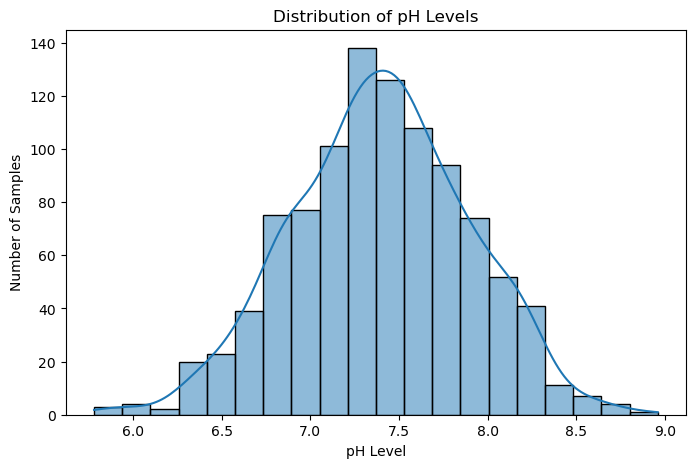

In [7]:
#PH LEVEL
plt.figure(figsize=(8,5))

sns.histplot(df['pH_Level'], bins=20, kde=True)

plt.title('Distribution of pH Levels')
plt.xlabel('pH Level')
plt.ylabel('Number of Samples')
plt.show()

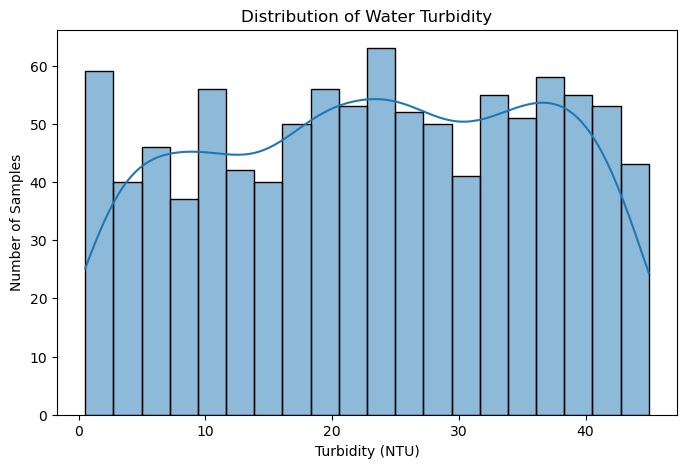

In [8]:
#TURBIDITY DIST
plt.figure(figsize=(8,5))

sns.histplot(df['Turbidity_NTU'], bins=20, kde=True)

plt.title('Distribution of Water Turbidity')
plt.xlabel('Turbidity (NTU)')
plt.ylabel('Number of Samples')
plt.show()

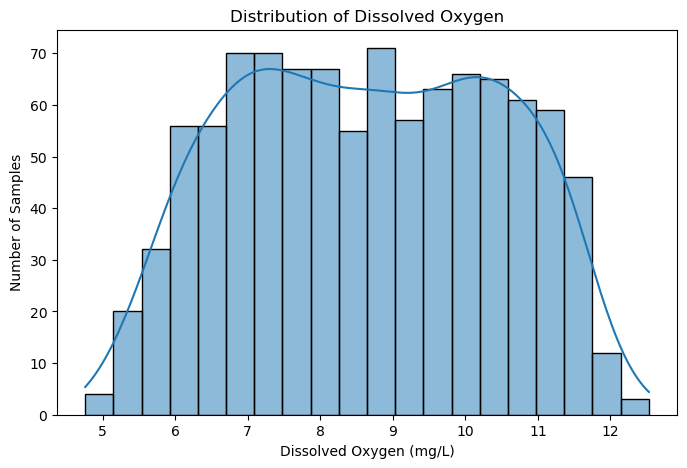

In [9]:
#DISSOLVE O2 DIST
plt.figure(figsize=(8,5))

sns.histplot(df['Dissolved_Oxygen_mgL'], bins=20, kde=True)

plt.title('Distribution of Dissolved Oxygen')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Number of Samples')
plt.show()

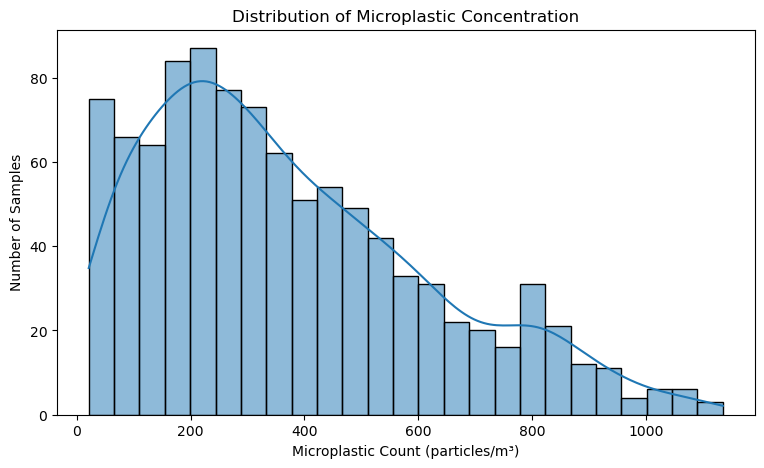

In [11]:
#MICROPLASTIC  COUNT
#MAIN
plt.figure(figsize=(9,5))

sns.histplot(
    df['Microplastic_Count_per_m3'],
    bins=25,
    kde=True
)

plt.title('Distribution of Microplastic Concentration')
plt.xlabel('Microplastic Count (particles/m³)')
plt.ylabel('Number of Samples')
plt.show()

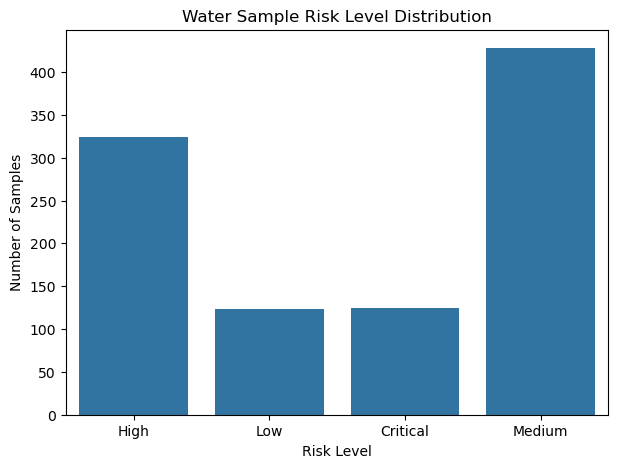

In [12]:
#RISK LEVEL DIST
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Risk_Level'
)

plt.title('Water Sample Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Samples')
plt.show()

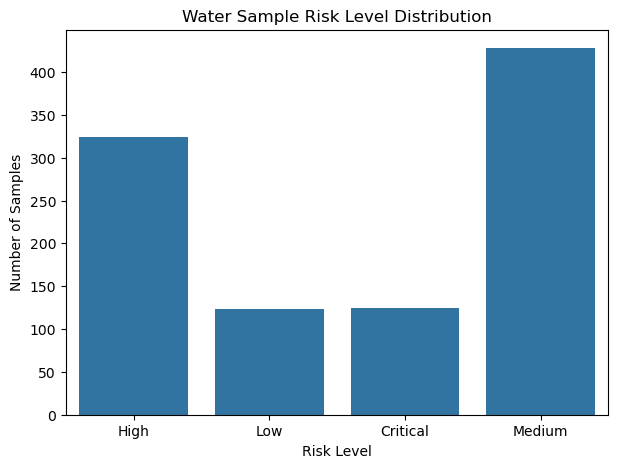

In [13]:
#MICROPLASTIC COUNT-BY-RISK-LEVELL
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Risk_Level'
)

plt.title('Water Sample Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Samples')
plt.show()

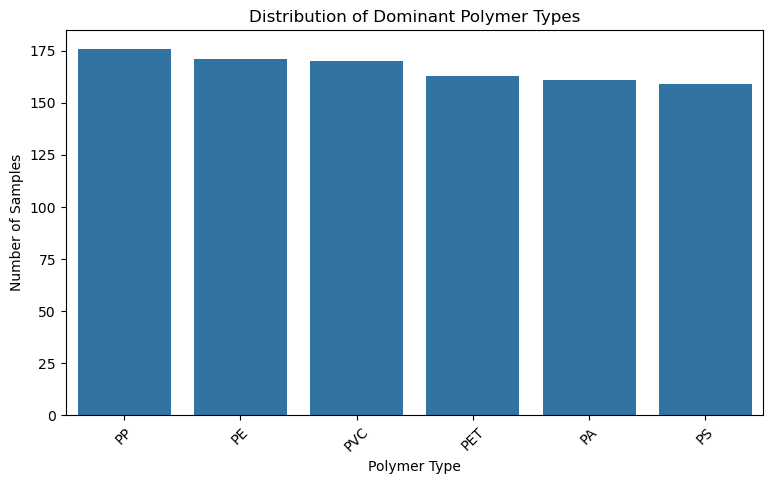

In [14]:
#DOMINNANT POLYMEER TYPES
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Dominant_Polymer',
    order=df['Dominant_Polymer'].value_counts().index
)

plt.title('Distribution of Dominant Polymer Types')
plt.xlabel('Polymer Type')
plt.ylabel('Number of Samples')

plt.xticks(rotation=45)
plt.show()

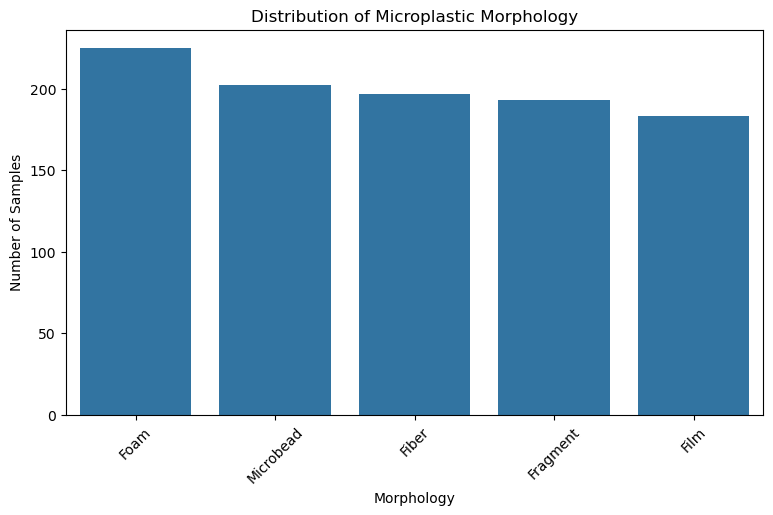

In [15]:
#MORPHOLOGY DOMINNANT
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Dominant_Morphology',
    order=df['Dominant_Morphology'].value_counts().index
)

plt.title('Distribution of Microplastic Morphology')
plt.xlabel('Morphology')
plt.ylabel('Number of Samples')

plt.xticks(rotation=45)
plt.show()

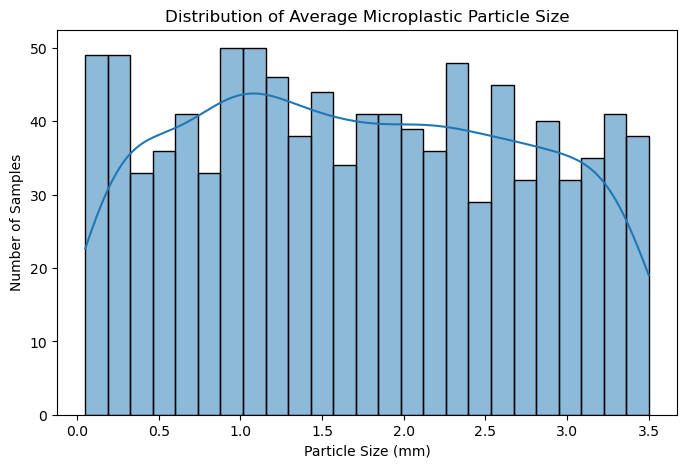

In [16]:
#AVG PARTICLE SIZE DIST
plt.figure(figsize=(8,5))

sns.histplot(
    df['Average_Particle_Size_mm'],
    bins=25,
    kde=True
)

plt.title('Distribution of Average Microplastic Particle Size')
plt.xlabel('Particle Size (mm)')
plt.ylabel('Number of Samples')
plt.show()

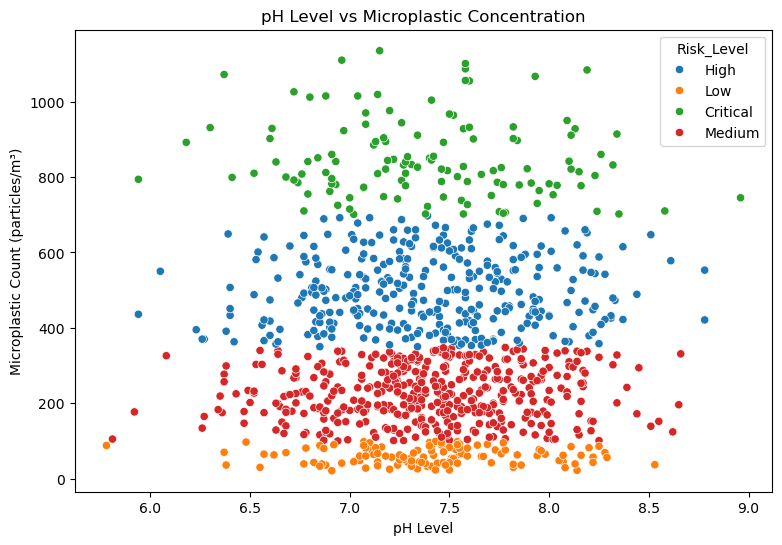

In [17]:
#MICROPLAST COUNT -VS- PH
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='pH_Level',
    y='Microplastic_Count_per_m3',
    hue='Risk_Level'
)

plt.title('pH Level vs Microplastic Concentration')
plt.xlabel('pH Level')
plt.ylabel('Microplastic Count (particles/m³)')

plt.show()

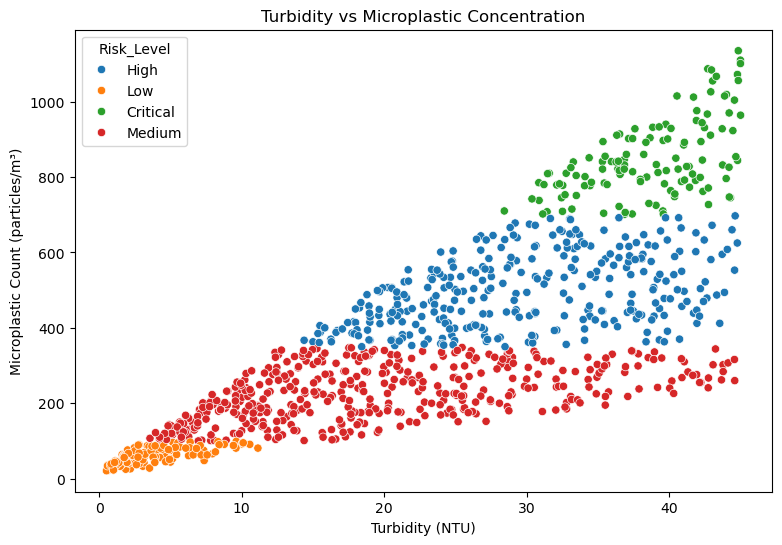

In [18]:
#TURBIDITY VS MICROPLAS
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Turbidity_NTU',
    y='Microplastic_Count_per_m3',
    hue='Risk_Level'
)

plt.title('Turbidity vs Microplastic Concentration')
plt.xlabel('Turbidity (NTU)')
plt.ylabel('Microplastic Count (particles/m³)')

plt.show()

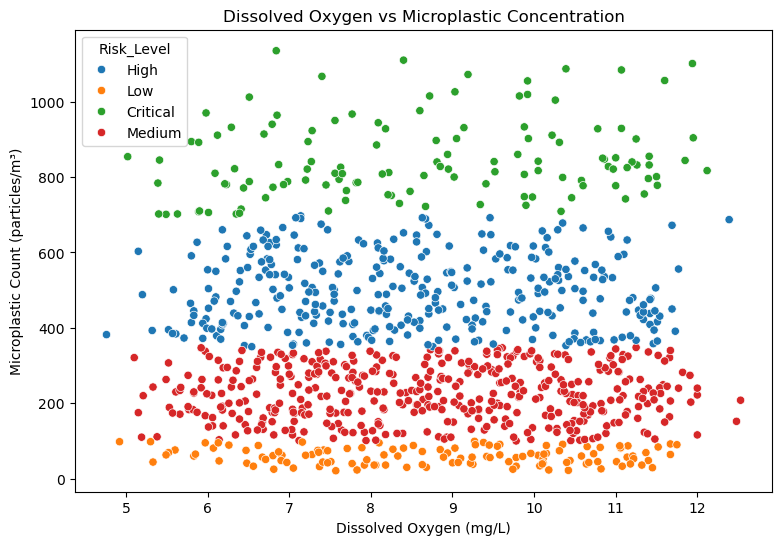

In [19]:
#DISS O2 VS MICROPLAST COUNT
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Dissolved_Oxygen_mgL',
    y='Microplastic_Count_per_m3',
    hue='Risk_Level'
)

plt.title('Dissolved Oxygen vs Microplastic Concentration')
plt.xlabel('Dissolved Oxygen (mg/L)')
plt.ylabel('Microplastic Count (particles/m³)')

plt.show()

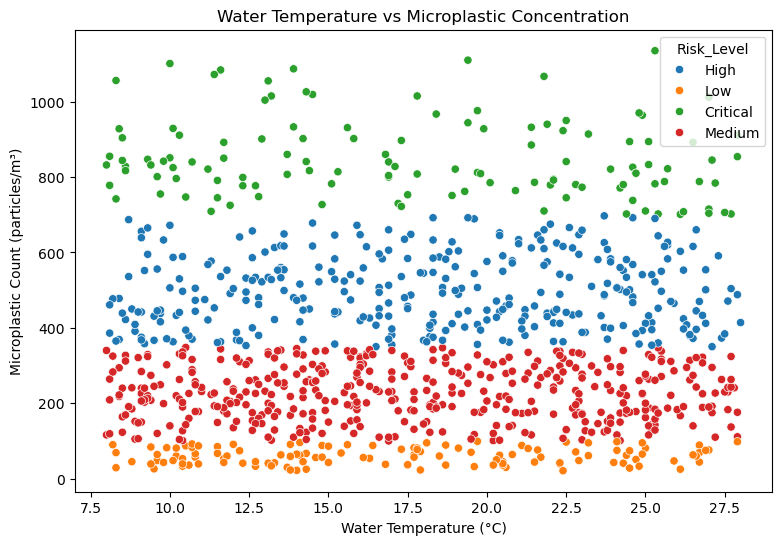

In [20]:
#H2O TEMPP VS MICROPLST COUNT
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Water_Temp_C',
    y='Microplastic_Count_per_m3',
    hue='Risk_Level'
)

plt.title('Water Temperature vs Microplastic Concentration')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Microplastic Count (particles/m³)')

plt.show()

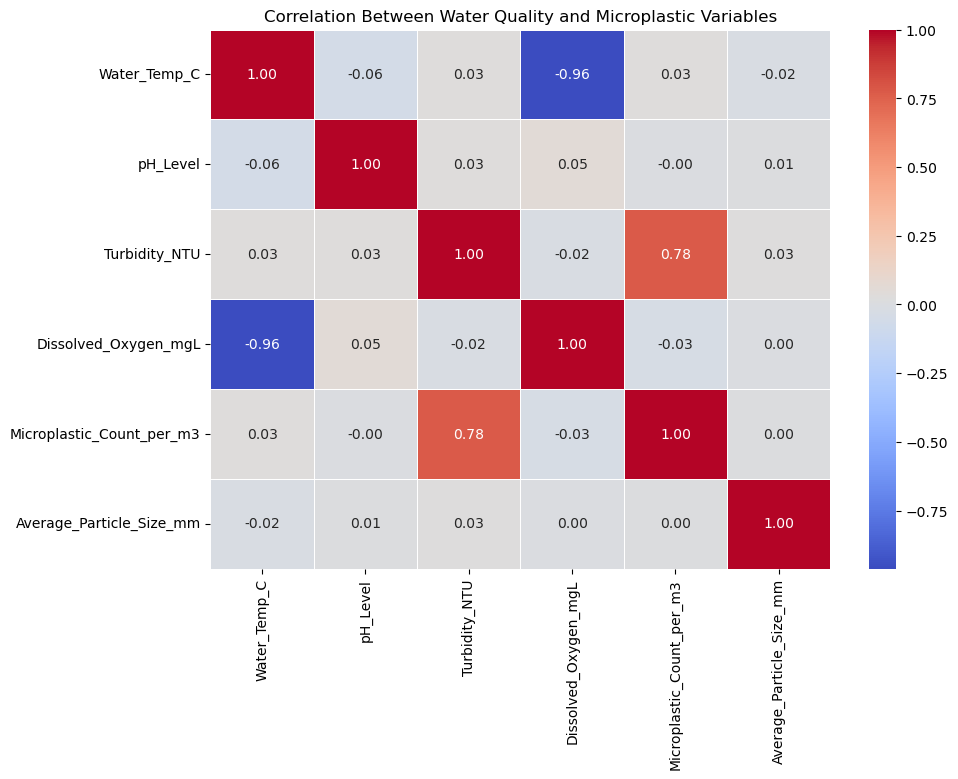

In [22]:
#Correlation heatmap
numeric_columns = [
    'Water_Temp_C',
    'pH_Level',
    'Turbidity_NTU',
    'Dissolved_Oxygen_mgL',
    'Microplastic_Count_per_m3',
    'Average_Particle_Size_mm'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Water Quality and Microplastic Variables')

plt.show()

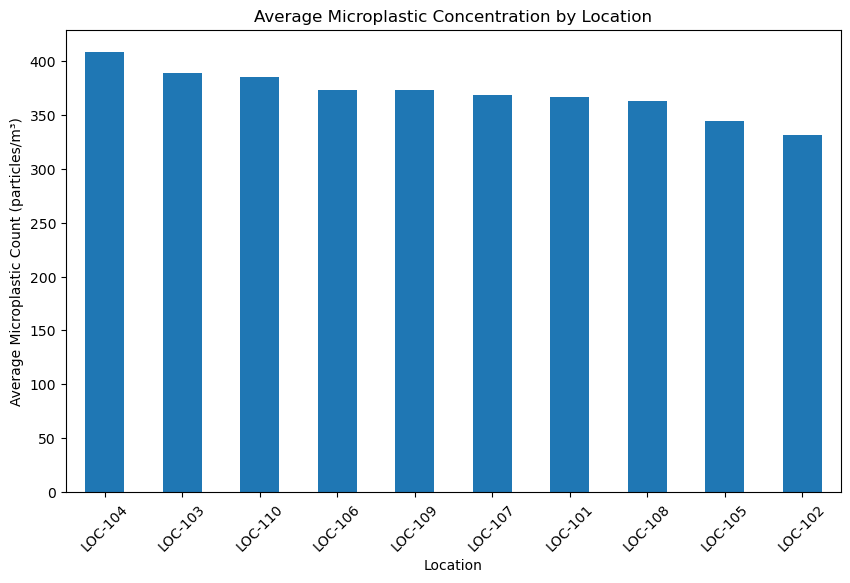

In [23]:
#Microplastic count by location
location_avg = (
    df.groupby('Location_ID')['Microplastic_Count_per_m3']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

location_avg.plot(kind='bar')

plt.title('Average Microplastic Concentration by Location')
plt.xlabel('Location')
plt.ylabel('Average Microplastic Count (particles/m³)')

plt.xticks(rotation=45)
plt.show()

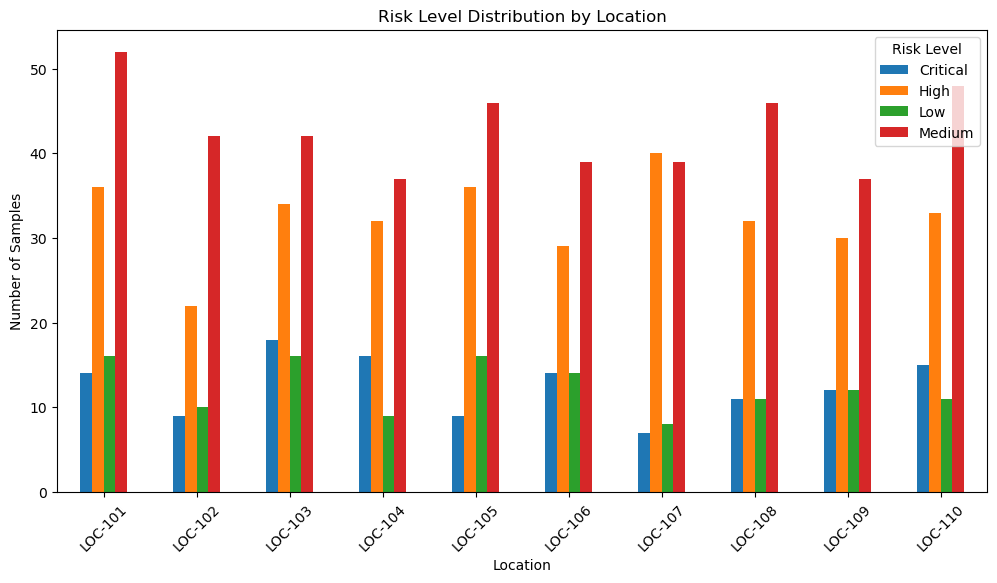

In [24]:
#Risk level by location
risk_location = pd.crosstab(
    df['Location_ID'],
    df['Risk_Level']
)

risk_location.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Risk Level Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Number of Samples')

plt.xticks(rotation=45)
plt.legend(title='Risk Level')

plt.show()

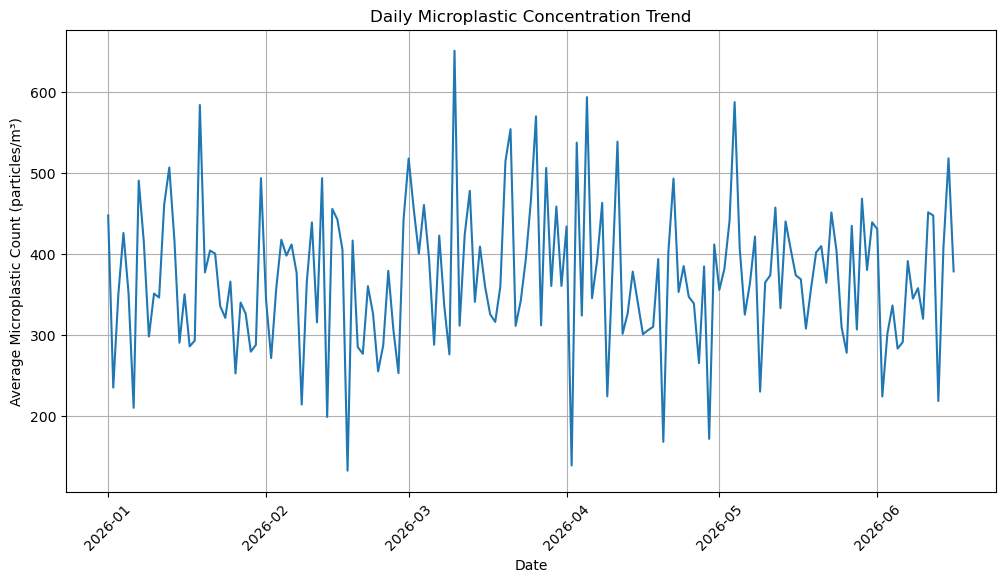

In [25]:
#Microplastic trend over time
daily_microplastic = (
    df.set_index('Timestamp')
      .resample('D')['Microplastic_Count_per_m3']
      .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    daily_microplastic.index,
    daily_microplastic.values
)

plt.title('Daily Microplastic Concentration Trend')
plt.xlabel('Date')
plt.ylabel('Average Microplastic Count (particles/m³)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

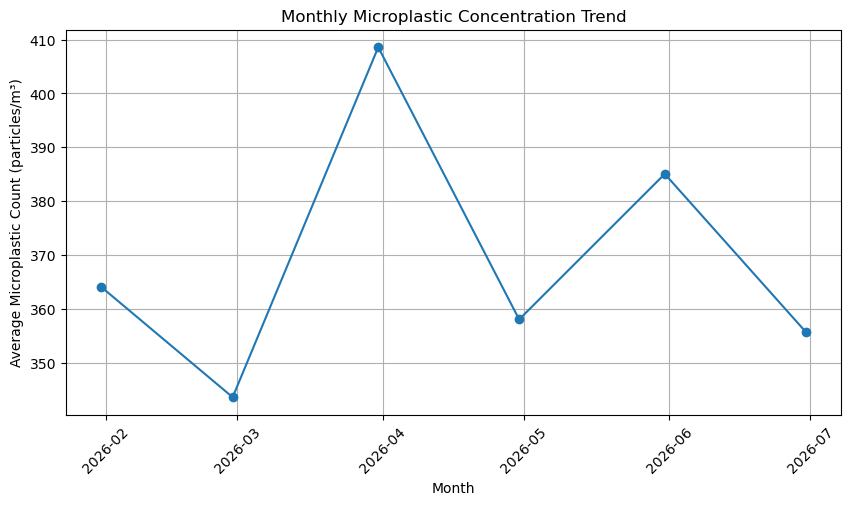

In [26]:
#Monthly microplastic trend
monthly_microplastic = (
    df.set_index('Timestamp')
      .resample('ME')['Microplastic_Count_per_m3']
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_microplastic.index,
    monthly_microplastic.values,
    marker='o'
)

plt.title('Monthly Microplastic Concentration Trend')
plt.xlabel('Month')
plt.ylabel('Average Microplastic Count (particles/m³)')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

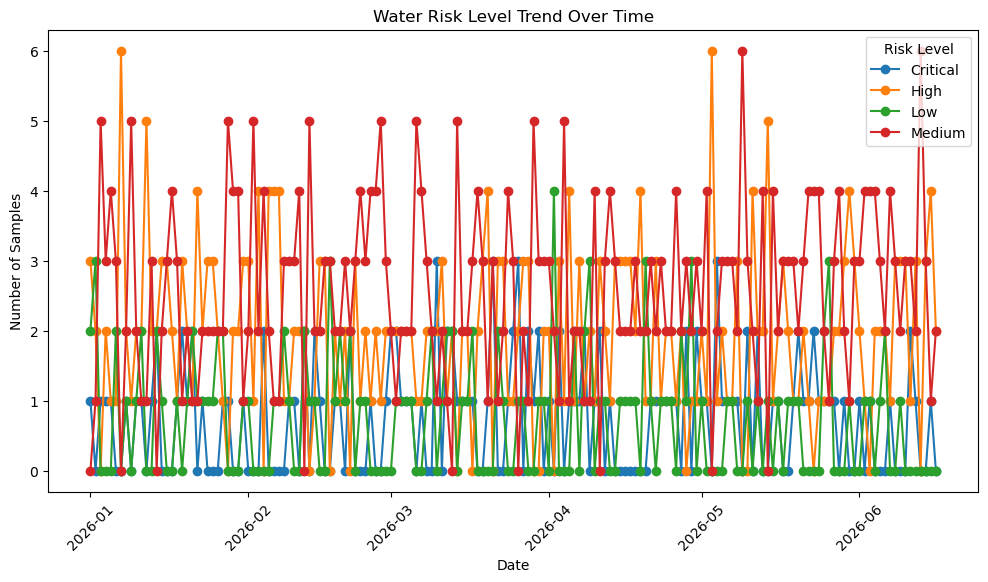

In [27]:
#Risk level over time
risk_time = pd.crosstab(
    df['Timestamp'].dt.date,
    df['Risk_Level']
)

risk_time.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Water Risk Level Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Samples')

plt.xticks(rotation=45)
plt.legend(title='Risk Level')

plt.show()

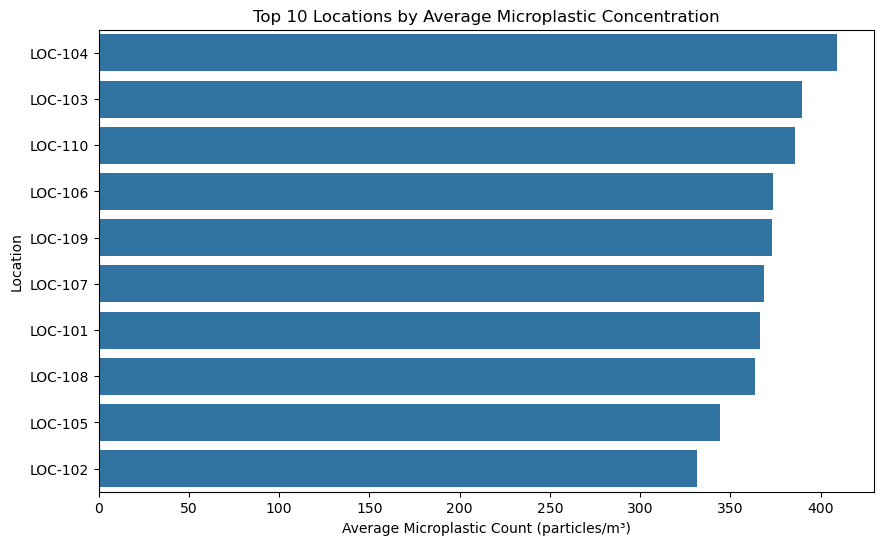

In [28]:
#Top locations with highest microplastic contamination
top_locations = (
    df.groupby('Location_ID')['Microplastic_Count_per_m3']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title('Top 10 Locations by Average Microplastic Concentration')
plt.xlabel('Average Microplastic Count (particles/m³)')
plt.ylabel('Location')

plt.show()